In [1]:
'''
Author: Niscienc 60505912+2099193635@users.noreply.github.com
Date: 2026-03-06 21:59:44
LastEditors: Niscienc 60505912+2099193635@users.noreply.github.com
LastEditTime: 2026-03-07 16:45:20
FilePath: \VTCM_PYTHON\main_simulation.ipynb
Description: 

Copyright (c) 2026 by ${git_name_email}, All Rights Reserved. 
'''
from configs.parameters import VehicleParams, Antiyawer_parameters, ExtraForceElements_parameters
from physics_modules.suspension import SuspensionSystem
import numpy as np

<>:1: SyntaxWarning: invalid escape sequence '\V'
<>:1: SyntaxWarning: invalid escape sequence '\V'
C:\Users\20991\AppData\Local\Temp\ipykernel_33836\2896109443.py:1: SyntaxWarning: invalid escape sequence '\V'
  '''
c:\VTCM_PYTHON\configs\parameters.py:281: SyntaxWarning: invalid escape sequence '\c'
  curve_file_dir: str = 'configs\curve_parameters.csv',
c:\VTCM_PYTHON\configs\parameters.py:282: SyntaxWarning: invalid escape sequence '\g'
  gradient_file_dir: str = 'configs\gradient_parameters.csv',


### 

In [ ]:
print("================ 测试 1:高速客车 (基础与加噪) ================")
# 1. 默认初始化 (高速客车)
veh_emu = VehicleParams(vehicle_type='高速客车')
# suspension = SuspensionSystem(veh_emu)
# (如果 sim 和 rail 尚未写好，可以先注释掉这两行)
# rail = RailParams()
# sim = IntegrationParams()
# sim.setup(veh_emu)

print(f"当前状态：无噪声基础模型 [{veh_emu.vehicle_type}]")
print(f"车体基础质量 Mc: {veh_emu.Mc} kg")
print(f"静轮重 P0: {veh_emu.P0:.2f} N")

print("\n--- 正在为数据集生成加噪 ---")
veh_emu.randomize_for_dataset(noise_ratio=0.15)
# sim.setup(veh_emu, random_speed=True)

print(f"当前状态：加噪扰动后 (噪声比例 ±15%)")
print(f"加噪车体质量 Mc: {veh_emu.Mc:.2f} kg")
print(f"新静轮重 P0: {veh_emu.P0:.2f} N")

================ 测试 1:高速客车 (基础与加噪) ================
当前状态：无噪声基础模型 [高速客车]
车体基础质量 Mc: 34000.0 kg
静轮重 P0: 55917.00 N

--- 正在为数据集生成加噪 ---
当前状态：加噪扰动后 (噪声比例 ±15%)
加噪车体质量 Mc: 31175.67 kg
新静轮重 P0: 53584.52 N


In [ ]:
print("\n================ 测试 2:多车型拓扑切换 (重载货车) ================")
# 2. 切换为重载货车进行测试
veh_freight = VehicleParams(vehicle_type='普通货车_重车')

print(f"当前状态：无噪声基础模型 [{veh_freight.vehicle_type}]")
print(f"车体基础质量 Mc: {veh_freight.Mc} kg")
print(f"货车独有摇枕质量 MB: {veh_freight.MB} kg")
# 验证底层的 P0 计算是否成功应用了货车的 1摇枕+2侧架 公式
print(f"静轮重 P0: {veh_freight.P0:.2f} N")

In [ ]:
print("\n================ 测试 3:抗蛇行减振器 (高速客车) ================")
# 3. 验证抗蛇行减振器矩阵切片
antiyaw = Antiyawer_parameters()
print(f"抗蛇行减振器刚度 Kantiyawer: {antiyaw.kantiyawer:.1e} N/m")
print(f"横向跨距之半 dsc: {antiyaw.dsc} m")
print(f"提取的非线性阻尼速度节点 (yaw_damper_v): \n{antiyaw.yaw_damper_v}")
print(f"提取的非线性阻尼力节点 (yaw_damper_f): \n{antiyaw.yaw_damper_f}")

In [ ]:
print("\n================ 测试 4：额外力元参数 (高速客车) ================")
# 4. 验证依赖 Lc 的额外力元动态计算
veh_emu_base = VehicleParams(vehicle_type='高速客车')
print(f"获取当前车型 [{veh_emu_base.vehicle_type}] 的半定距 Lc: {veh_emu_base.Lc} m")

# 将 Lc 喂给 ExtraForceElements_parameters
extra_forces = ExtraForceElements_parameters(Lc=veh_emu_base.Lc)

print("\n--- 节点与减振器基础参数 ---")
print(f"一系垂向减振器阻尼 Cz_pvd: {extra_forces.Cz_pvd} N.s/m")
print(f"转臂节点纵向刚度 Knodex: {extra_forces.Knodex:.1e} N/m")

print("\n--- 动态位置与插值矩阵计算验证 ---")
print(f"左侧 SLD 纵向位置数组 Lsld_Car_L: {extra_forces.Lsld_Car_L}")
print(f"右侧 SLD 纵向位置数组 Lsld_Car_R: {extra_forces.Lsld_Car_R}")
print(f"二系横向减振器(SLD)速度节点: {extra_forces.lat_damper_v}")
print(f"二系横向减振器(SLD)阻尼力节点: {extra_forces.lat_damper_f}")

In [ ]:
print("\n================ 测试 5:轨道参数 (60轨) ================")
from configs.parameters import VehicleParams, Antiyawer_parameters, ExtraForceElements_parameters, RailParams
track = RailParams(rail_type='CHN60')
print(f"  -> 轨道系统: [{track.rail_type}] 钢轨结构参数加载完毕 (轨距: {track.gauge}mm, 轨底坡: 1:40)")

In [ ]:
print("\n================ 测试 6:扣件参数 (KV模型扣件) ================")
from configs.parameters import VehicleParams, Antiyawer_parameters, ExtraForceElements_parameters, RailParams, Fastener_KV
Fastener = Fastener_KV(fastener_type='Standard_KV')
print(f"  -> 扣件类型: [{Fastener.fastener_type}] 参数加载完毕 (扣件间距 : {Fastener.Lkj*1000:.1f}mm, 扣件垂向刚度: {Fastener.Kkjv} N/m)")

In [ ]:
print("\n================ 测试 7:扣件参数 (FDKV模型扣件) ================")
from configs.parameters import FastenerFDKVParams
fastener_fdkv = FastenerFDKVParams(temperature=-30, fdkv_switch='On')
print(f"  -> 扣件类型: [FDKV分数阶模型] 参数加载完毕 (环境温度: {fastener_fdkv.temperature}℃, 模块开关: {fastener_fdkv.fdkv_switch})")
print(f"  -> 提取的分数阶导数阶次: {fastener_fdkv.alpha_FDKV}, 分数阶刚度 K_alpha: {fastener_fdkv.K_alpha:.2e}")
print(f"  -> 记忆截断积分步数 IntStep: {fastener_fdkv.IntStep}")

In [ ]:
print("\n================ 测试 8:轨下结构参数 (标准轨下模型) ================")
from configs.parameters import Subrail_Params 

subrail_standard = Subrail_Params(subrail_type='Standard_Subrail')
print(f"  -> 轨下结构类型: [{subrail_standard.subrail_type}] 参数加载完毕")
print(f"  -> 轨枕质量 Ms: {subrail_standard.Ms} kg, 轨枕侧滚惯量 Js: {subrail_standard.Js:.2f} kg.m^2")
print(f"  -> 道床垂向刚度 Kbv: {subrail_standard.Kbv:.2e} N/m, 路基垂向阻尼 Cfv: {subrail_standard.Cfv:.2e} N.s/m")

In [ ]:
print("\n================ 测试 9: 线路几何参数  ================")
from configs.parameters import RealTrackAlignment
track_alignment = RealTrackAlignment(
    cache_file_dir='configs/track_cache.npz', force_rebuild=True
)
print(f"  -> 线路解析器加载完毕！")
print(f"  -> 网格精度 ds: {track_alignment.ds} m")
print(f"  -> 全局里程范围: {track_alignment.s_grid[0]/1000:.3f} km ~ {track_alignment.s_grid[-1]/1000:.3f} km")

# 提取里程进行测试

test_s_straight = 801000.0  
k1, h1, g1, R1, Theta1, Lc1, case1, L1_1, L2_1, Lz1_1, Lz2_1, hcg1, S1, ZH1 = track_alignment.get_geometry_at(test_s_straight)

print(f"\n  [查询点 1: 里程 s = {test_s_straight/1000:.3f} km] -> 预期: 纯直线段")
print(f"    - 微观瞬态: 曲率 k = {k1:.6f} 1/m, 瞬时超高 h = {h1:.3f} m, 坡度 g = {g1*1000:.1f} ‰")
print(f"    - 宏观参数: 曲线方向 curvecase = {case1} (0代表纯直线), 目标半径 R = {R1:.1f} m")
print(f"    - 入缓点 ZH = {ZH1:.1f} m")
# 测试点 2：圆曲线内部测试 (801.8 km，位于第一个左转曲线 801.193~801.711 内)
test_s_curve = 801800.0  
k2, h2, g2, R2, Theta2, Lc2, case2, L1_2, L2_2, Lz1_2, Lz2_2, hcg2, S2, ZH2 = track_alignment.get_geometry_at(test_s_curve)

print(f"\n  [查询点 2: 里程 s = {test_s_curve/1000:.3f} km] -> 预期: 左转圆曲线")
print(f"    - 微观瞬态: 曲率 k = {k2:.6f} 1/m, 瞬时超高 h = {h2:.3f} m, 坡度 g = {g2*1000:.1f} ‰")
print(f"    - 宏观参数: 曲线方向 curvecase = {case2} (1代表左转), 目标半径 R = {R2:.1f} m, 设计超高 hcg = {hcg2:.3f} m")
print(f"    - 几何特征: 前缓和 L1 = {L1_2} m, 圆曲线 Lc = {Lc2:.1f} m, 后缓和 L2 = {L2_2} m")
print(f"    - 夹直线段: 前夹直线 Lz1 = {Lz1_2:.1f} m, 后夹直线 Lz2 = {Lz2_2:.1f} m")
print(f"    - 入缓点 ZH = {ZH2:.1f} m")

In [ ]:
print("\n================ 测试 10: 钢轨求解模态数量参数  ================")
from configs.parameters import ModesParameters
modes_params = ModesParameters()
print(f"  -> 钢轨模态求解数量参数加载完毕！")
print(f"  -> 当前设置的钢轨模态求解数量: {modes_params.NV} 阶垂向模态, {modes_params.NL} 阶横向模态, {modes_params.NT} 阶扭转模态")

In [ ]:
print("\n================ 测试 11: 积分参数  ================")
from configs.parameters import VehicleParams, Fastener_KV, IntegrationParams, RealTrackAlignment
import numpy as np
veh_emu = VehicleParams(vehicle_type='高速客车')
fastener_kv = Fastener_KV(fastener_type='Standard_KV')
track_alignment = RealTrackAlignment(
    cache_file_dir='configs/track_cache.npz'
)
S0_start = 801000.0
integration = IntegrationParams(
    Lc=veh_emu.Lc,          # 直接从车辆实例导入
    Lt=veh_emu.Lt,          # 直接从车辆实例导入
    R=veh_emu.R,            # 直接从车辆实例导入
    Lkj=fastener_kv.Lkj,    # 直接从扣件实例导入
    Vx_set=300.0,           # 设定车速 300 km/h
    Tz=5.0,                 # 设定仿真总时长 5 s
    S0_mileage=S0_start     # 设定地球绝对坐标起点
)
print(f"\n -> [控制中心] 积分控制器初始化完成！")
print(f"    计算得角速度: {integration.omega:.2f} rad/s")
print(f"    计算得仿真总步数: {integration.Nt} 步 (步长 {integration.Tstep}s)")
print(f"    安全走行距离截断检算: Lz = {integration.Lz:.2f} m")
for step in range(3):
    t = step * integration.Tstep
    # 1. 相对坐标推进 (车辆在柔性轨道上前进了多少)
    current_X = integration.X0 + integration.Vc * t
    # 2. 绝对坐标映射 
    current_s = integration.get_absolute_mileage(t)
    print(f"    Step {step}: t={t:.4f}s | 相对位移 X={current_X:.4f}m | 绝对里程 s={current_s/1000:.6f}km")

In [ ]:
print("\n================ 测试 12: 全局仿真功能开关控制 ================")
from configs.parameters import ExtraforceElementSwitch
sim_switches = ExtraforceElementSwitch(
        Switch_CurveTrack='On',
        Switch_2PointContact='On'
    )
print(" -> [系统配置] 仿真全局开关初始化完成。")
print(f"    曲线轨道模块: {sim_switches.Switch_CurveTrack}")
print(f"    胶垫分区模块: {sim_switches.Switch_PadZone}")
print(f"    两点接触模块: {sim_switches.Switch_2PointContact}")
sim_switches.is_active('Switch_CurveTrack')

In [ ]:
print("\n================ 测试 13: 曲线解析计算器 (CurveFunction)  ================")
from configs.parameters import RealTrackAlignment, CurveFunction
track_alignment = RealTrackAlignment()
Vc_test = 300 / 3.6
print(" -> [系统配置] 真实线路解析器初始化完成。")
print(f"    测试车速: {Vc_test:.2f} m/s")
# 测试工况 A: 纯直线段
s_straight = 801000.0
geom_straight = track_alignment.get_geometry_at(s_straight)
R, Theta, Lc, case, L1, L2, Lz1, Lz2, hcg, S, ZH_abs = geom_straight[3:]

print(f"\n -> [工况 A] 绝对里程 {s_straight/1000:.3f} km")
if case == 0:
    print(f"    检测状态: 纯直线段 (curvecase = {case})")
    print("    处理逻辑: 无需实例化 CurveFunction，所有曲率和侧倾导数直接置为 0.0")
    dTheta_dt = 0.0
    ddTheta_dt = 0.0
    dK_dt = 0.0
else:
    print("    [警告] 这里不应该是曲线段！")

# 测试工况 B: 缓和曲线段
s_curve = 802000.0
geom_curve = track_alignment.get_geometry_at(s_curve)
R, Theta, Lc, case, L1, L2, Lz1, Lz2, hcg, S, ZH_abs = geom_curve[3:]
print(f"\n -> [工况 B] 绝对里程 {s_curve/1000:.3f} km")
if case != 0:
    print(f"    检测状态: 曲线段 (curvecase = {case}, 目标半径 R = {R} m)")
    
    # 1. 核心映射：绝对地球里程 -> 局部相对里程
    offset = s_curve - ZH_abs
    local_x = Lz1 + offset
    print(f"    坐标映射: 距离该曲线起点偏移 {offset:.2f}m -> 映射至 CurveFunction 局部里程 local_x = {local_x:.2f}m")
    
    # 2. 依赖注入：将查表得到的 10 个宏观参数直接喂给 CurveFunction
    curve_math = CurveFunction(
        Rcurve=R, Thetacurve=Theta, curvecase=case,
        L1=L1, L2=L2, Lz1=Lz1, Lz2=Lz2, hcg=hcg, S=S, v=Vc_test
    )
    print("    -> CurveFunction 解析实例创建成功！")
    
    # 3. 提取完美的解析数值和时间导数
    current_Theta = curve_math.Theta_mile(local_x)
    dTheta_dt = curve_math.dTheta_mile(local_x)
    ddTheta_dt = curve_math.ddTheta_mile(local_x)
    dK_dt = curve_math.dK_mile(local_x)
    
    print("\n    [精确数学解析输出]")
    print(f"      瞬时超高角 Theta: {current_Theta:.6f} rad")
    print(f"      侧倾角速度 dTheta/dt: {dTheta_dt:.6f} rad/s")
    print(f"      侧倾角加速度 ddTheta/dt^2: {ddTheta_dt:.6f} rad/s^2")
    print(f"      曲率激增率 dK/dt: {dK_dt:.6f} 1/(m·s)")

In [ ]:
print("\n================ 测试 14: 廓形导入  ================")
import numpy as np
import matplotlib.pyplot as plt
rail = np.loadtxt('Profile_file/rail_fade.txt')
wheel = np.loadtxt('Profile_file/wheel_fade.txt')
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(rail[:, 0], rail[:, 1], label='Rail Profile')
plt.title('Rail Profile')
plt.xlabel('Horizontal Distance (mm)')
plt.ylabel('Vertical Distance (mm)')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(wheel[:, 0], wheel[:, 1], label='Wheel Profile', color='orange')
plt.title('Wheel Profile')
plt.xlabel('Horizontal Distance (mm)')
plt.ylabel('Vertical Distance (mm)')
plt.grid()


================ 测试 15/16: 全链路多轮对轨道激扰样本生成与时空可视化 ================
 -> 初始化不平顺生成器: Vc=59.72 m/s, Tstep=0.0001, Nt=50000, Tz=5.0
 -> 正在进行多轮对时空耦合激扰矩阵生成...
 -> [生成成功] 维度: 4 x 50001
 -> [物理信息] 总时长: 5.00 s
 -> 病害参数: a=0 m, L=0 m


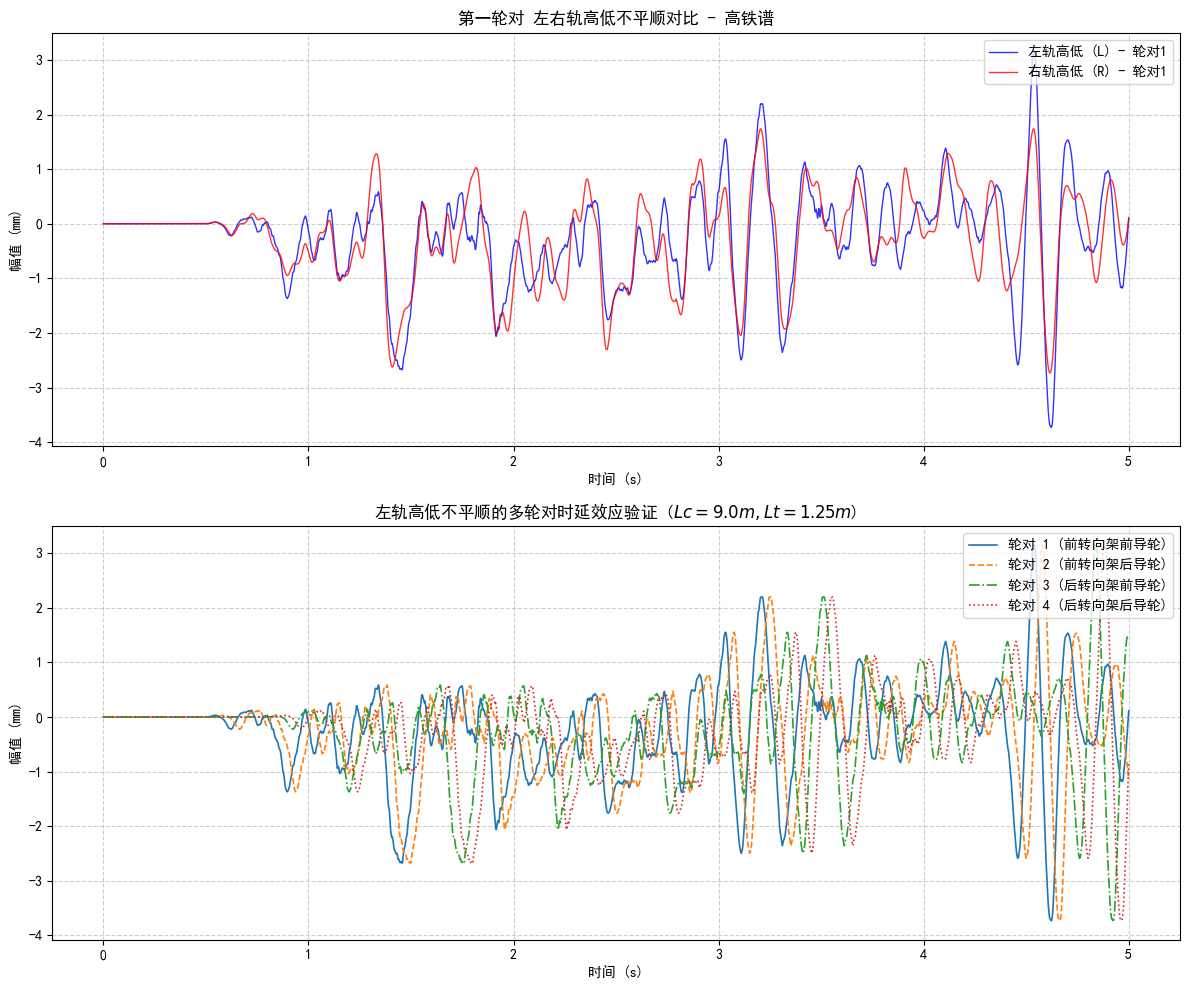

In [3]:
print("\n================ 测试 15/16: 全链路多轮对轨道激扰样本生成与时空可视化 ================")
from defect_injector.irregularity import Irregularity
import numpy as np
import matplotlib.pyplot as plt

# ===================== 1) 参数区 =====================
sim_Vc = 215 / 3.6      # m/s
sim_Tstep = 1e-4        # s
sim_Nt = 50_000      # 100 s
sim_Tz = 5.0          # s (与 Nt*Tstep 一致)

# 外部不平顺配置
external_mileage_mode = 'absolute'   # 'absolute' / 'relative'
type2_mode = '空间谱'                 # 空间谱: 第1列按里程解释
defect_switch = 'off'

# 新功能：指定起始里程（与文件第1列同单位；当前文件为 km）
start_mileage = 272.8185727202

# 绘图横坐标：'time' 或 'mileage'
x_axis_mode = 'time'

# 显示窗口（None 表示全程）
xlim_top = None
xlim_bottom = None

print(f" -> 初始化不平顺生成器: Vc={sim_Vc:.2f} m/s, Tstep={sim_Tstep}, Nt={sim_Nt}, Tz={sim_Tz}")

# ===================== 2) 构建对象 =====================
track_simulator = Irregularity(
    Lc=9.0, Lt=1.25, Vc=sim_Vc, Tstep=sim_Tstep, Tz=sim_Tz, Nt=sim_Nt,
    type='外部导入',
    Type2=type2_mode,
    powerSpectrum_type='高铁谱',
    mile=2000,
    external_mileage_mode=external_mileage_mode,
    external_distance_unit='km',
    external_start_mileage=start_mileage,
 )

# 使用 / 避免 Windows 反斜杠转义问题
base = 'preprocessing/静检数据/呼局/20210416/处理后/静检上行20210416-271-278.merged.aligned.external'
prefix = '静检上行20210416-271-278.merged.aligned'
external_files = {
    'VL': f'{base}/{prefix}_VL.txt',
    'VR': f'{base}/{prefix}_VR.txt',
    'LL': f'{base}/{prefix}_LL.txt',
    'LR': f'{base}/{prefix}_LR.txt',
    'start_mileage': start_mileage,
}

print(" -> 正在进行多轮对时空耦合激扰矩阵生成...")
out = track_simulator.excitation_irregularity(
    defect_switch=defect_switch,
    external_files=external_files
)

# ===================== 3) 结果解包 =====================
bz_L, by_L, dbz_L, dby_L, bz_R, by_R, dbz_R, dby_R, defect_a, defect_L = out
num_wheelsets, total_points = bz_L.shape
sim_time_total = total_points * sim_Tstep
print(f" -> [生成成功] 维度: {num_wheelsets} x {total_points}")
print(f" -> [物理信息] 总时长: {sim_time_total:.2f} s")
print(f" -> 病害参数: a={defect_a} m, L={defect_L} m")

# ===================== 4) 构造横坐标 =====================
time_axis = np.arange(total_points) * sim_Tstep

# 若 absolute 模式，可用外部文件首里程作为绝对起点
s0_abs = None
if external_mileage_mode.lower() == 'absolute':
    try:
        s0_abs = float(np.loadtxt(external_files['VL'])[0, 0])
    except Exception:
        s0_abs = None

if s0_abs is None:
    mileage_axis = sim_Vc * time_axis
    x_label_mileage = '里程 (m, 相对)'
else:
    mileage_axis = s0_abs + sim_Vc * time_axis
    x_label_mileage = '里程 (m, 绝对)'

if x_axis_mode == 'mileage':
    x = mileage_axis
    x_label = x_label_mileage
else:
    x = time_axis
    x_label = '时间 (s)'

# ===================== 5) 绘图 =====================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 1, figsize=(12, 10), dpi=100)

# 图1：第一轮对左右轨高低
axes[0].plot(x, bz_L[0, :] * 1000, label='左轨高低 (L) - 轮对1', color='blue', linewidth=1.0, alpha=0.8)
axes[0].plot(x, bz_R[0, :] * 1000, label='右轨高低 (R) - 轮对1', color='red', linewidth=1.0, alpha=0.8)
axes[0].set_title(f'第一轮对 左右轨高低不平顺对比 - {track_simulator.powerSpectrum_type}')
axes[0].set_xlabel(x_label)
axes[0].set_ylabel('幅值 (mm)')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(loc='upper right')
if xlim_top is not None:
    axes[0].set_xlim(*xlim_top)

# 图2：左轨4轮对时延效应
axes[1].plot(x, bz_L[0, :] * 1000, label='轮对 1 (前转向架前导轮)', color='#1f77b4', linewidth=1.2)
axes[1].plot(x, bz_L[1, :] * 1000, label='轮对 2 (前转向架后导轮)', color='#ff7f0e', linewidth=1.2, linestyle='--')
axes[1].plot(x, bz_L[2, :] * 1000, label='轮对 3 (后转向架前导轮)', color='#2ca02c', linewidth=1.2, linestyle='-.')
axes[1].plot(x, bz_L[3, :] * 1000, label='轮对 4 (后转向架后导轮)', color='#d62728', linewidth=1.2, linestyle=':')
axes[1].set_title(f'左轨高低不平顺的多轮对时延效应验证 ($Lc={track_simulator.Lc}m, Lt={track_simulator.Lt}m$)')
axes[1].set_xlabel(x_label)
axes[1].set_ylabel('幅值 (mm)')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='upper right')
if xlim_bottom is not None:
    axes[1].set_xlim(*xlim_bottom)

plt.tight_layout()
plt.show()

================ 准备启动轮轨几何前处理引擎测试 ================

 -> 轮轨廓形数据加载完毕...
 -> 几何前处理引擎执行完毕！

================ 关键几何参数核对 ================
标准轨距: 1435.0 mm
车轮名义滚动圆半径: 430.0 mm
钢轨轨底坡角 (1:40): 1.43°
踏面区数据点数: 5656, 轮缘区数据点数: 2344


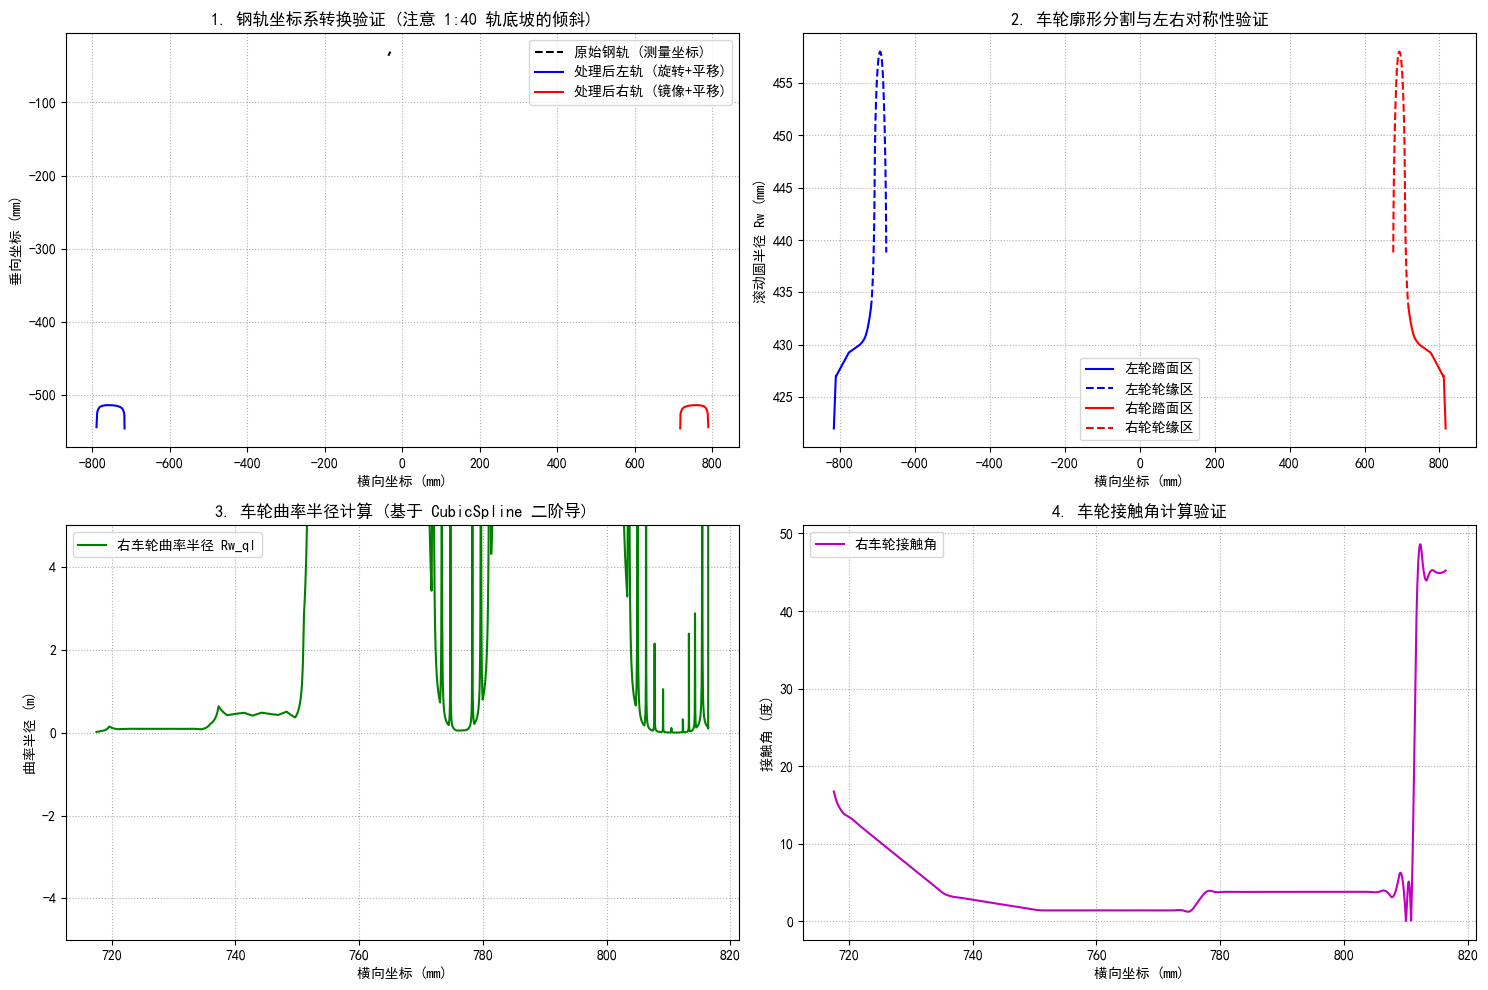

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from physics_modules.contact_geometry import WheelRailContactProcessor

print("================ 准备启动轮轨几何前处理引擎测试 ================\n")


rail = np.loadtxt('Profile_file/rail_fade.txt')
wheel = np.loadtxt('Profile_file/wheel_fade.txt')

# 生成数据并送入你写的处理器
rail_raw, wheel_raw = rail, wheel
print(" -> 轮轨廓形数据加载完毕...")

processor = WheelRailContactProcessor()
info = processor.process_pre_information(rail_raw, wheel_raw)
print(" -> 几何前处理引擎执行完毕！\n")

# ---------------- 2. 核心信息打印核对 ----------------
print("================ 关键几何参数核对 ================")
print(f"标准轨距: {info.gauge*1000} mm")
print(f"车轮名义滚动圆半径: {info.Rwo*1000} mm")
print(f"钢轨轨底坡角 (1:40): {np.rad2deg(info.cant):.2f}°")
print(f"踏面区数据点数: {len(info.WprofR_y)}, 轮缘区数据点数: {len(info.WprofR2_y)}")

# ---------------- 3. 可视化诊断 (最重要的一环) ----------------
# 设置中文字体 (防止图表乱码)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

fig = plt.figure(figsize=(15, 10))

# --- 子图 1: 原始与旋转后的钢轨 ---
ax1 = plt.subplot(2, 2, 1)
ax1.plot(rail_raw[0,:], rail_raw[1,:], 'k--', label='原始钢轨 (测量坐标)')
ax1.plot(info.rprofL_y * 1000, info.rprofL_z * 1000, 'b-', label='处理后左轨 (旋转+平移)')
ax1.plot(info.rprofR_y * 1000, info.rprofR_z * 1000, 'r-', label='处理后右轨 (镜像+平移)')
ax1.set_title("1. 钢轨坐标系转换验证 (注意 1:40 轨底坡的倾斜)")
ax1.set_xlabel("横向坐标 (mm)")
ax1.set_ylabel("垂向坐标 (mm)")
ax1.legend()
ax1.grid(True, linestyle=':')

# --- 子图 2: 车轮左右侧对称性验证 ---
ax2 = plt.subplot(2, 2, 2)
ax2.plot(info.WprofL_y * 1000, info.RwL * 1000, 'b-', label='左轮踏面区')
ax2.plot(info.WprofL2_y * 1000, info.RwL2 * 1000, 'b--', label='左轮轮缘区')
ax2.plot(info.WprofR_y * 1000, info.RwR * 1000, 'r-', label='右轮踏面区')
ax2.plot(info.WprofR2_y * 1000, info.RwR2 * 1000, 'r--', label='右轮轮缘区')
ax2.set_title("2. 车轮廓形分割与左右对称性验证")
ax2.set_xlabel("横向坐标 (mm)")
ax2.set_ylabel("滚动圆半径 Rw (mm)")
ax2.legend()
ax2.grid(True, linestyle=':')

# --- 子图 3: 曲率半径计算验证 (最容易出现除零爆炸的地方) ---
ax3 = plt.subplot(2, 2, 3)
ax3.plot(info.WprofR_y * 1000, info.RwR_ql, 'g-', label='右车轮曲率半径 Rw_ql')
ax3.set_title("3. 车轮曲率半径计算 (基于 CubicSpline 二阶导)")
ax3.set_xlabel("横向坐标 (mm)")
ax3.set_ylabel("曲率半径 (m)")
# 限制 Y 轴范围，防止直线段的极大曲率破坏画面比例
ax3.set_ylim(-5, 5) 
ax3.legend()
ax3.grid(True, linestyle=':')

# --- 子图 4: 接触角计算验证 ---
ax4 = plt.subplot(2, 2, 4)
ax4.plot(info.WprofR_y * 1000, np.rad2deg(info.detR), 'm-', label='右车轮接触角')
ax4.set_title("4. 车轮接触角计算验证")
ax4.set_xlabel("横向坐标 (mm)")
ax4.set_ylabel("接触角 (度)")
ax4.legend()
ax4.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 假设你的模块已经正确保存在 physics_modules 文件夹下
# 如果在同一文件中测试，请确保上文的 WheelRailContactProcessor 和 WheelRailInteraction 已定义
from physics_modules.contact_geometry import WheelRailContactProcessor
from physics_modules.wheel_rail_contact import WheelRailInteraction

print("================ [主控中心] 轮轨力学联合解算测试 ================\n")

# =====================================================================
# 阶段 1: 离线预处理 (对应主程序 for ii=1:Nt 循环之外的初始化)
# =====================================================================
print(">>> 阶段 1: 执行离线几何预处理...")

rail = np.loadtxt('Profile_file/rail_fade.txt')
wheel = np.loadtxt('Profile_file/wheel_fade.txt')

rail_raw, wheel_raw = rail, wheel

# 1.2 几何信息提取 (整个仿真只执行 1 次)
processor = WheelRailContactProcessor()
geom_info = processor.process_pre_information(rail_raw, wheel_raw)

# 1.3 实例化接触求解器
interaction_solver = WheelRailInteraction(geom_info)
print(">>> 阶段 1 完毕: 几何预处理与求解器挂载成功！\n")

# =====================================================================
# 阶段 2: 积分步循环内状态抽取 (模拟 for ii=1:Nt 内部某一时刻)
# =====================================================================
print(">>> 阶段 2: 抽取当前积分步 (ii) 的车辆/轨道状态...")

# 假设列车运行速度 300 km/h
vc = 83.33  # m/s
Rwo = 0.43  # 车轮滚动圆半径
omg = vc / Rwo  # 轮对名义滚动角速度 (rad/s)

# 模拟第 1 个轮对 (nw=0) 的空间振动状态
# 假设轮对发生了 8mm 的向右横移 (导致右侧轮缘逼近钢轨)
Yw_current = 0.008  # 轮对横移 8mm
Zw_current = 0.001  # 轮对垂向跳动 1mm
phiw_current = 0.002 # 轮对微小侧滚角
psiw_current = 0.001 # 轮对微小摇头角

# 假设钢轨是刚性的 (或取自轨道子结构的动态位移)，此处赋 0
LRKX_Y = LRKX_Z = thetaL = 0.0
RRKX_Y = RRKX_Z = thetaR = 0.0

# 轨道不平顺 (此处赋 0)
Irrez_L = Irrey_L = VIrrez_L = VIrrey_L = 0.0
Irrez_R = Irrey_R = VIrrez_R = VIrrey_R = 0.0

# 轮对绝对速度状态 (VXwo = vc, Vwbeta = omg)
VXwo, VYwo, VZwo = vc, 0.01, -0.01
Vwphi, Vwbeta, Vwpsi = 0.0, omg, 0.0

# 钢轨振动速度 (此处赋 0)
VrkxY_L = VrkxZ_L = VrkxO_L = 0.0
VrkxY_R = VrkxZ_R = VrkxO_R = 0.0


# =====================================================================
# 阶段 3: 调用空间两点接触算法求解接触力
# =====================================================================
print(">>> 阶段 3: 正在求解复杂空间接触力...")

# 传入刚才抽取的所有状态
forces = interaction_solver.calculate_two_point_contact(
    nw=0, vc=vc, omg=omg,
    Zw=Zw_current, Yw=Yw_current, phiw=phiw_current, psiw=psiw_current,
    LRKX_Y=LRKX_Y, LRKX_Z=LRKX_Z, thetaL=thetaL,
    RRKX_Y=RRKX_Y, RRKX_Z=RRKX_Z, thetaR=thetaR,
    VXwo=VXwo, VYwo=VYwo, VZwo=VZwo, Vwphi=Vwphi, Vwbeta=Vwbeta, Vwpsi=Vwpsi,
    VrkxY_L=VrkxY_L, VrkxZ_L=VrkxZ_L, VrkxO_L=VrkxO_L,
    VrkxY_R=VrkxY_R, VrkxZ_R=VrkxZ_R, VrkxO_R=VrkxO_R,
    Irrez_L=Irrez_L, Irrey_L=Irrey_L, VIrrez_L=VIrrez_L, VIrrey_L=VIrrey_L,
    Irrez_R=Irrez_R, Irrey_R=Irrey_R, VIrrez_R=VIrrez_R, VIrrey_R=VIrrey_R
)

print("\n================ [解算结果报告] ================")
print(f"轮对向右横移量: {Yw_current * 1000:.1f} mm")
print("-" * 45)
print("【第一接触点 (踏面区) 受力】")
print(f"  左侧法向力 (FNz_L): {forces['FNz_L'] / 1000:.2f} kN")
print(f"  右侧法向力 (FNz_R): {forces['FNz_R'] / 1000:.2f} kN")
print(f"  左侧横向力 (FNy_L): {forces['FNy_L'] / 1000:.2f} kN")
print(f"  右侧横向力 (FNy_R): {forces['FNy_R'] / 1000:.2f} kN")

print("\n【第二接触点 (轮缘区) 受力】")
print(f"  左侧轮缘法向力 (FNz_L2): {forces['FNz_L2'] / 1000:.2f} kN")
print(f"  右侧轮缘法向力 (FNz_R2): {forces['FNz_R2'] / 1000:.2f} kN")

print("\n【蠕滑力 (Kalker + Shen氏修正)】")
print(f"  左侧纵向蠕滑力: {forces['CreepForce_L'] / 1000:.2f} kN")
print(f"  右侧纵向蠕滑力: {forces['CreepForce_R'] / 1000:.2f} kN")

print("-" * 45)
# 简单验证物理规律：向右横移 8mm，右侧轮缘应大概率发生贴靠，左侧轮缘必定悬空
if forces['FNz_R2'] > 1.0:
    print("✅ 物理诊断：检测到右侧轮缘贴靠！(发生两点接触)")
elif forces['FNz_L2'] > 1.0:
    print("❌ 物理诊断：警告！左侧发生异常贴靠。")
else:
    print("✅ 物理诊断：处于纯踏面接触状态 (横移量未触发轮缘接触)。")

# =====================================================================
# 阶段 4: 结果可视化 (数据大屏展示)
# =====================================================================
print("\n>>> 阶段 4: 生成可视化图表...")

# 设置中文字体，防止乱码
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

fig = plt.figure(figsize=(16, 5))

# --- 子图 1: 法向力分布 (踏面 vs 轮缘) ---
ax1 = plt.subplot(1, 3, 1)
labels_N = ['左踏面 (L1)', '右踏面 (R1)', '左轮缘 (L2)', '右轮缘 (R2)']
# 提取法向力 (转为 kN)
forces_N = [
    forces.get('FNz_L', 0)/1000, 
    forces.get('FNz_R', 0)/1000, 
    forces.get('FNz_L2', 0)/1000, 
    forces.get('FNz_R2', 0)/1000
]
bars1 = ax1.bar(labels_N, forces_N, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
ax1.set_ylabel('法向接触力 (kN)')
ax1.set_title('法向力分布 (检测两点接触)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
# 在柱子上标注数值
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}', ha='center', va='bottom')

# --- 子图 2: 横向力与纵向蠕滑力 ---
ax2 = plt.subplot(1, 3, 2)
labels_T = ['左横向力', '右横向力', '左纵向蠕滑', '右纵向蠕滑']
# 提取切向力 (转为 kN，只取踏面的作为主要展示)
forces_T = [
    forces.get('FNy_L', 0)/1000, 
    forces.get('FNy_R', 0)/1000, 
    forces.get('CreepForce_L', 0)/1000, 
    forces.get('CreepForce_R', 0)/1000
]
bars2 = ax2.bar(labels_T, forces_T, color=['#8172B3', '#937860', '#8172B3', '#937860'])
ax2.set_ylabel('横向/纵向力 (kN)')
ax2.set_title('横向力与蠕滑力分布')
ax2.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars2:
    yval = bar.get_height()
    # 对于负数，调整文字位置
    offset = 1 if yval >= 0 else -3
    ax1.text(bar.get_x() + bar.get_width()/2, yval + offset, f'{yval:.1f}', ha='center', va='bottom')

# --- 子图 3: 轮轨相对位置动态示意图 (核心图) ---
ax3 = plt.subplot(1, 3, 3)

# 1. 绘制钢轨 (不动)
ax3.plot(geom_info.rprofL_y * 1000, geom_info.rprofL_z * 1000, 'k-', linewidth=2, label='钢轨')
ax3.plot(geom_info.rprofR_y * 1000, geom_info.rprofR_z * 1000, 'k-', linewidth=2)

# 2. 绘制偏移后的车轮 (偏移 Yw_current)
# 【修复1】：向下平移对齐算法的基准坐标系 (改为减去 detZwj0)
shift_z = -interaction_solver.detZwj0 * 1000 - Zw_current * 1000
wheelL_y_shifted = (geom_info.WprofL_y + Yw_current) * 1000
wheelL_z_shifted = (-geom_info.RwL) * 1000 + shift_z
wheelR_y_shifted = (geom_info.WprofR_y + Yw_current) * 1000
wheelR_z_shifted = (-geom_info.RwR) * 1000 + shift_z

ax3.plot(wheelL_y_shifted, wheelL_z_shifted, 'b--', label='偏移后车轮')
ax3.plot(wheelR_y_shifted, wheelR_z_shifted, 'b--')

# 3. 标注接触点
# 【修复2】：将 MATLAB 吐出的局部坐标，还原为全局作图坐标
wp_L1 = forces.get('wpointL1', 0)
wp_R1 = forces.get('wpointR1', 0)
wp_L2 = forces.get('wpointL2', 0)
wp_R2 = forces.get('wpointR2', 0)

global_wp_L1 = wp_L1 - geom_info.wdis/2
global_wp_R1 = wp_R1 + geom_info.wdis/2
global_wp_L2 = wp_L2 - geom_info.wdis/2
global_wp_R2 = wp_R2 + geom_info.wdis/2

if forces.get('FNz_L', 0) > 0:
    ax3.scatter((global_wp_L1 + Yw_current)*1000, np.interp(global_wp_L1, geom_info.WprofL_y, -geom_info.RwL)*1000 + shift_z, color='r', s=100, zorder=5, label='踏面接触点')
if forces.get('FNz_R', 0) > 0:
    ax3.scatter((global_wp_R1 + Yw_current)*1000, np.interp(global_wp_R1, geom_info.WprofR_y, -geom_info.RwR)*1000 + shift_z, color='r', s=100, zorder=5)
if forces.get('FNz_L2', 0) > 0:
    ax3.scatter((global_wp_L2 + Yw_current)*1000, np.interp(global_wp_L2, geom_info.WprofL_y, -geom_info.RwL)*1000 + shift_z, color='g', s=100, marker='*', zorder=5, label='轮缘接触点')
if forces.get('FNz_R2', 0) > 0:
    ax3.scatter((global_wp_R2 + Yw_current)*1000, np.interp(global_wp_R2, geom_info.WprofR_y, -geom_info.RwR)*1000 + shift_z, color='g', s=100, marker='*', zorder=5)

ax3.set_title(f'轮轨空间相对位置 (横移 = {Yw_current*1000:.1f} mm)')
ax3.set_xlabel('横向坐标 (mm)')
ax3.set_ylabel('垂向坐标 (mm)')
ax3.legend(loc='lower center')
ax3.grid(True, linestyle=':')

# 【修复3】：解除视野封印，让坐标轴自适应展示整个轮轨截面！
# (去掉了之前的 set_ylim 和 set_xlim)
plt.tight_layout()
plt.show()




In [ ]:
import numpy as np

from physics_modules.equation_of_motion import GeneralForceAssembler

print("================ [系统诊断] 广义力组装器测试启动 ================\n")

# =====================================================================
# 1. 构造 Mock (虚拟) 对象，替代真实的配置参数和状态类
# =====================================================================
class MockVehicleParams:
    """模拟车辆结构参数 (简化版)"""
    def __init__(self):
        self.Mw = 2000.0   # 轮对质量 (kg)
        self.Mt = 3000.0   # 构架质量 (kg)
        self.Mc = 40000.0  # 车体质量 (kg)
        self.Jwy = 150.0   # 轮对绕 Y 轴转动惯量 (验证陀螺效应)
        
        self.dw = 1.0      # 一系弹簧横向半距
        self.Htw = 0.5     # 轮轴中心至一系弹簧高度
        self.ds = 1.0      # 二系弹簧横向半距
        self.HBt = 0.5     # 构架质心至二系高度
        self.Lt = 1.25     # 转向架固定轴距之半
        self.dsc = 1.0     # 抗蛇行减振器横向半距
        self.HcB = 0.5     # 车体质心至二系高度
        self.Lc = 8.0      # 车辆定距之半
        self.Rwo = 0.43    # 轮对名义滚动圆半径

class MockIntegrationParams:
    """模拟积分器参数"""
    def __init__(self):
        self.vc = 83.33    # 运行速度 300 km/h

class MockStepState:
    """模拟车辆某一个积分步的瞬时状态"""
    def __init__(self):
        # 提取组装器需要的项 (4个轮对的状态)
        self.V_RollW = np.array([0.01, 0.01, -0.01, -0.01])  # 侧滚角速度
        self.V_SpinW = np.array([193.0, 193.0, 193.0, 193.0])# 自旋角速度 (近似 vc/Rwo)
        self.V_YawW  = np.array([0.005, -0.005, 0.005, -0.005]) # 摇头角速度
        self.X_YawW  = np.array([0.002, -0.002, 0.002, -0.002]) # 摇头角位移

# =====================================================================
# 2. 构造虚拟的 悬挂力 和 轮轨接触力 字典 (全为 NumPy 数组)
# =====================================================================
# 1. 模拟一二系悬挂力 (注意：一系长度必须为 4，二系长度必须为 2)
susp_forces_mock = {
    'Fxf_L': np.ones(4) * 100,   'Fxf_R': np.ones(4) * -100,
    'Fyf_L': np.ones(4) * 200,   'Fyf_R': np.ones(4) * 200,
    'Fzf_L': np.ones(4) * 50000, 'Fzf_R': np.ones(4) * 50000,
    'Fxt_L': np.ones(2) * 500,   'Fxt_R': np.ones(2) * -500,
    'Fyt_L': np.ones(2) * 600,   'Fyt_R': np.ones(2) * 600,
    'Fzt_L': np.ones(2) * 100000,'Fzt_R': np.ones(2) * 100000,
    'Mr':    np.ones(2) * 1000,
    'Fxs_L': np.ones(2) * 300,   'Fxs_R': np.ones(2) * -300
}

# 2. 模拟轮轨两点接触力 
wr_forces_mock = {
    'FNx_L': np.ones(4) * 100,  'FNy_L': np.ones(4) * -200, 'FNz_L': np.ones(4) * 60000,
    'FNx_R': np.ones(4) * 100,  'FNy_R': np.ones(4) * 200,  'FNz_R': np.ones(4) * 60000,
    'FNx_L2': np.zeros(4),      'FNy_L2': np.zeros(4),      'FNz_L2': np.zeros(4),
    'FNx_R2': np.zeros(4),      'FNy_R2': np.zeros(4),      'FNz_R2': np.zeros(4),
    'MLy': np.ones(4) * 10,     'MLz': np.ones(4) * -10, 
    'MRy': np.ones(4) * 10,     'MRz': np.ones(4) * 10,
    'rL': np.ones(4) * 0.43,    'rR': np.ones(4) * 0.43,
    'rL2': np.ones(4) * 0.43,   'rR2': np.ones(4) * 0.43,
    'a0': np.ones(4) * 0.75,    'a02': np.ones(4) * 0.75
}

# =====================================================================
# 3. 运行组装器并进行核心断言 (Assertions)
# =====================================================================
try:
    vp = MockVehicleParams()
    ip = MockIntegrationParams()
    state = MockStepState()
    
    # 实例化组装器
    assembler = GeneralForceAssembler(veh_params=vp, integration_params=ip)
    
    # 调用大一统组装函数
    GF_SYSTEM = assembler.assemble_GF_SYSTEM(state, susp_forces_mock, wr_forces_mock)
    
    print("✅ [测试 1: 运行通过] 代码无抛出异常，所有矩阵切片和广播 (Broadcasting) 计算合法。")
    
    # 检查维度 (应该等于 35，因为我们目前的拼接是：车体5 + 构架10 + 轮对20)
    # (如果后续加上了 8 个轴箱自由度，这里会是 43)
    expected_dim = 35 
    assert GF_SYSTEM.shape[0] == expected_dim, f"维度错误: 期望 {expected_dim}，但得到 {GF_SYSTEM.shape[0]}"
    print(f"✅ [测试 2: 维度检查] 广义力矩阵维度为 {GF_SYSTEM.shape[0]}，与多体动力学拓扑完美吻合！")
    
    # 物理逻辑检查：车体垂向受力 Z 向 (Mc) 
    # 包含重力 (Mc*g) 和 4个 二系弹簧垂向支撑力 (-Fzt)
    expected_Car_Z = vp.Mc * 9.81 - np.sum(susp_forces_mock['Fzt_L']) - np.sum(susp_forces_mock['Fzt_R'])
    assert np.isclose(GF_SYSTEM[1], expected_Car_Z), "车体垂向力组装逻辑有误！"
    print(f"✅ [测试 3: 物理逻辑] 车体垂向受力计算精确通过，标量化结果: {GF_SYSTEM[1]:.2f} N")
    
    print("\n🎉 恭喜！GeneralForceAssembler 引擎运转极其健康，可以接入主积分器！")
    
except Exception as e:
    print(f"❌ [测试失败] 发生了错误: {str(e)}")

In [ ]:
import numpy as np
from configs.parameters import VehicleParams, Antiyawer_parameters, ExtraForceElements_parameters
from configs.topology import SystemTopology # 必须导入拓扑模块
from physics_modules.suspension import SuspensionSystem

print("================ 准备启动悬挂力学引擎测试 ================\n")

# ---------------- 1. 初始化参数与环境 ----------------
model_name = '高速客车'
veh = VehicleParams(vehicle_type=model_name)
ap = Antiyawer_parameters()
ep = ExtraForceElements_parameters(Lc=veh.Lc)

# 实例化悬挂系统
suspension = SuspensionSystem(veh_params=veh, antiyawer_params=ap, extra_params=ep)

# 实例化拓扑管理器（用于将数组转换为 StepState 对象）
# 这里的 Nt 和 Nsub 仅用于占位，测试悬挂模块时并不影响结果
topo = SystemTopology(Nt=1, Nsub=1) 

print(f"正在加载 [{model_name}] 参数底座...")
print(f"预计算的一系静态承载力: {suspension.static_force_pre:.2f} N")
print(f"预计算的二系静态承载力: {suspension.static_force_sec:.2f} N\n")

# ---------------- 2. 构造模拟状态 ----------------
# 在新架构中，状态是从全局大向量 X_full 中切出来的
# 假设系统总自由度足够大
X_full = np.zeros(200)
V_full = np.zeros(200)

# 模拟位移：车体下沉 5mm (index 1), 车体摇头 0.002 rad (index 4)
X_full[1] = 0.005 
X_full[4] = 0.002
# 模拟速度：车体垂向速度 0.01 m/s (index 1)
V_full[1] = 0.01

# --- 关键步骤：使用 topo.extract_state 将数组打包为 StepState 对象 ---
current_state = topo.extract_state(X_full, V_full, Vc=83.33) # 83.33 m/s = 300 km/h

# ---------------- 3. 测试 1：直线工况 ----------------
print("================ 测试 1：动态受力解算 (直线工况) ================")
forces_straight = suspension.compute_forces(
    state=current_state,  # 传入对象而不是数组
    R_curve=np.array([np.inf, np.inf, np.inf]), 
    d_invR_dt=np.zeros(3)
)

print(f"二系垂向力 Fzt_L (含静态承载): {forces_straight['Fzt_L']} N")
print(f"一系横向力 Fyf_L: {forces_straight['Fyf_L']} N")

# ---------------- 4. 测试 2：曲线工况 ----------------
print("\n================ 测试 2：动态受力解算 (曲线工况) ================")
# 模拟 400m 半径曲线
R_400 = np.array([400.0, 400.0, 400.0])
forces_curve = suspension.compute_forces(
    state=current_state, 
    R_curve=R_400, 
    d_invR_dt=np.zeros(3)
)

print(f"直线时一系横向力 [0]: {forces_straight['Fyf_L'][0]:.2f} N")
print(f"曲线时一系横向力 [0]: {forces_curve['Fyf_L'][0]:.2f} N")
print("结论：横向偏置项已生效。")

# ---------------- 5. 测试 3：开关控制 ----------------
print("\n================ 测试 3：力元控制台面板测试 ================")
suspension.switches['antiyawer'] = 0.0 # 关闭抗蛇行
forces_disabled = suspension.compute_forces(current_state)

print(f"关闭后的抗蛇行力 Fxs_L: {forces_disabled['Fxs_L']} (应全为0)")
print("测试完成！")

In [ ]:
import os
root_dir = '.' # 以当前项目根目录为例

for dirpath, dirnames, filenames in os.walk(root_dir):
    print(f"当前目录: {dirpath}")
    
    # 打印该目录下的所有子文件夹
    for dirname in dirnames:
        print(f"  ├── [目录] {dirname}")
        
    # 打印该目录下的所有文件
    for filename in filenames:
        print(f"  └── [文件] {filename}")